In [2]:
from __future__ import annotations

import lhapdf

import numpy as np

from validphys.api import API
from validphys.fkparser import load_fktable
from validphys.loader import Loader
import matplotlib.pyplot as plt


# Generate data

## Theory ID 40001000

In [3]:
inp_p2 = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_P_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000, #208
}
inp_d2 = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_D_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000,
}

lcd_p2 = API.loaded_commondata_with_cuts(**inp_p2)
lcd_d2 = API.loaded_commondata_with_cuts(**inp_d2)

df_p2 = (
    lcd_p2.commondata_table.reset_index()
    .rename(
        columns={
            "kin1": "x",
            "kin2": "q2",
            "kin3": "y",
            "data": "F2_p",
            "stat": "error",
            "entry": "entry_p",
        },
    )
    .assign(idx_p=lambda df: df.index)
)
df_d2 = (
    lcd_d2.commondata_table.reset_index()
    .rename(
        columns={
            "kin1": "x",
            "kin2": "q2",
            "kin3": "y",
            "data": "F2_d",
            "stat": "error",
            "entry": "entry_d",
        },
    )
    .assign(idx_d=lambda df: df.index)
)

# Merge on (x, q2) to form F2_p - F2_d
mp = 0.938
mp2 = mp**2

#modify merge function to remove double counting
merged_df2 = df_p2.merge(df_d2, on=["x", "q2"], suffixes=("_p", "_d")).assign(
    y_val=lambda df: (df["F2_p"] - df["F2_d"]),
    F2_d = lambda df: (df["F2_d"]),
    w2=lambda df: df["q2"] * (1 - df["x"]) / df["x"] + mp2,
)

# remove duplicates to match 248 entries as in paper, for full 611 entries just comment out this line
merged_df2 = merged_df2.groupby(['x', 'q2', 'F2_d', 'entry_d']).first().reset_index()

# Extract q2_vals and y_real for later use
q2_vals2 = merged_df2["q2"].to_numpy()
y_real2 = merged_df2["y_val"].to_numpy()
np.save("Dataset/q2_vals_newth.npy", q2_vals2)
np.save("Dataset/y_real_newth.npy", y_real2)

In [4]:
entry_p_rel2 = merged_df2["entry_p"].to_numpy() - 1
entry_d_rel2 = merged_df2["entry_d"].to_numpy() - 1
print(entry_d_rel2)

q2_vals2 = merged_df2["q2"].to_numpy()

print(len(q2_vals2))

[  0   1  99 100   2   3   4 101 102 103 178 179   5   6   7   8   9 104
 105 106 107 180 181 182 183  10  11  12  13  14  15 108  16 109 110 111
 112 184 113 185 186 187 188  17  18  19  20  21  22  23  24 114  25 115
 189 116 117 190 118 191 119 192 193 194 195  26  27  28  29  30  31  32
 120  33 121 196  34 122  35 123 197 198 124 199 125 126 200 201 127 202
 203 204  36  37  38  39  40  41  42  43 128 129  44  45 130 205  46 131
 206  47 207 132 133 208 209 134 210 135 136 211 212 213  48  49  50  51
  52  53  54 137  55 138  56 214  57 139  58 215 140 216  59 141  60 217
 142  61 218 143 144 219 145 220 146 221 222 223  63  64  65  66  67 147
  68 148  69 224 149  70 150  71 225  72 151 226 227  73 152  74 153 228
  75 229 154 230 155 231 156 232 157 233 234  79  80  81 158  82 159 160
  83  84 161 235  85 162 236  86 237 163 164 238  87  88 165 239 166 240
  89 241 167 168 242 243 244  92 169  93 170 171  94 245 172  95 246  96
 247 173  97 174 248  98 249 175 250 176 251 177 25

In [5]:
import numpy as np
from validphys.api import API
from validphys.pineparser import pineappl_reader

theoryid = 40001000
t3_index = 2  # flavor index in FK table

# Load datasets (legacy names OK; they get mapped internally)
ds_p = API.dataset(dataset_input={"dataset": "BCDMS_NC_NOTFIXED_P_EM-F2"}, theoryid=theoryid, use_cuts="internal")
ds_d = API.dataset(dataset_input={"dataset": "BCDMS_NC_NOTFIXED_D_EM-F2"}, theoryid=theoryid, use_cuts="internal")

# Read PineAPPL FK tables for each dataset (often multiple sqrt(s) grids)
fk_p_list = [pineappl_reader(fkspec) for fkspec in ds_p.fkspecs]
fk_d_list = [pineappl_reader(fkspec) for fkspec in ds_d.fkspecs]

# If you truly need one combined FK table like the legacy case, you must pick the
# matching component for each datapoint. A simple starting point is to use the first.
fk_p2 = fk_p_list[0]
fk_d2 = fk_d_list[0]

print(fk_p2)

wp2 = fk_p2.get_np_fktable()  # (n_data_fk, n_flav, n_grid)
wd2 = fk_d2.get_np_fktable()

wp2_t3 = wp2[:, t3_index, :]
wd2_t3 = wd2[:, t3_index, :]

entry_p_rel2 = merged_df2["entry_p"].to_numpy() - 1
entry_d_rel2 = merged_df2["entry_d"].to_numpy() - 1

W2 = wp2_t3[entry_p_rel2] - wd2_t3[entry_d_rel2]  # (n_data, n_grid)
print(W2.shape)

# Save xgrid for later normalization
xgrid2 = fk_p2.xgrid.copy()  # (n_grid,)
print(fk_p2.xgrid.shape)
# Save for later use
np.save("Dataset/W_newth.npy", W2)
np.save("Dataset/xgrid_newth.npy", xgrid2)


FKTableData(hadronic=False, Q0=1.0, ndata=351, xgrid=array([0.00287387, 0.0043285 , 0.00649621, 0.00969916, 0.01437507,
       0.02108919, 0.03052158, 0.04341492, 0.06048003, 0.08228122,
       0.10914376, 0.14112081, 0.17802566, 0.21950413, 0.2651137 ,
       0.3143874 , 0.36687532, 0.42216678, 0.4798989 , 0.53975723,
       0.6014722 , 0.66481395, 0.72958684, 0.79562425, 0.86278393,
       0.93094408, 1.        ]), sigma=                   1             2             3             4             5   \
data x                                                                          
0    0   0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
     1   2.576106e-27  6.069118e-27  1.795509e-43  5.205035e-48 -7.173868e-44   
     2  -7.956479e-22 -1.387550e-21 -1.448743e-37 -3.155238e-39 -7.900809e-39   
     3   8.274516e-15  1.913565e-14  6.776172e-31  6.457974e-31 -3.157212e-31   
     4   6.553538e-10  1.117898e-09  1.526886e-25  1.096678e-25 -5.471530e-27   
...   

In [6]:
import numpy as np
from validphys.api import API

inp_p = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_P_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000, #208
}
inp_d = {
    "dataset_input": {"dataset": "BCDMS_NC_NOTFIXED_D_EM-F2", "variant": "legacy"},
    "use_cuts": "internal",
    "theoryid": 40001000,
}

params_cov = {
    "dataset_inputs": [inp_p["dataset_input"], inp_d["dataset_input"]],
    "use_cuts": "internal",
    "theoryid": 40001000,
}
cov_full2 = API.dataset_inputs_covmat_from_systematics(**params_cov)


# Your merged indices are in the ORIGINAL (pre-cut) dataset index space
idx_p_merge2 = merged_df2["idx_p"].to_numpy()
idx_d_merge2 = merged_df2["idx_d"].to_numpy()

n_p2 = len(df_p2)
# Extract the proton-proton, deuteron-deuteron, and proton-deuteron sub-blocks:
c_pp2 = cov_full2[:n_p2, :n_p2]  # shape = (Np, Np)
c_dd2 = cov_full2[n_p2:, n_p2:]  # shape = (Nd, Nd)
c_pd2 = cov_full2[:n_p2, n_p2:]  # shape = (Np, Nd)

# Restrict to matched points only (now safe)
c_pp_sub2 = c_pp2[np.ix_(idx_p_merge2, idx_p_merge2)]
c_dd_sub2 = c_dd2[np.ix_(idx_d_merge2, idx_d_merge2)]
c_pd_sub2 = c_pd2[np.ix_(idx_p_merge2, idx_d_merge2)]

# Cov for y = p - d  =>  Cov(y) = Cov(p)+Cov(d)-Cov(p,d)-Cov(d,p)
c_yy2 = c_pp_sub2 + c_dd_sub2 - c_pd_sub2 - c_pd_sub2.T

# Force exact symmetry (numerical)
c_yy2 = 0.5 * (c_yy2 + c_yy2.T)

print("c_yy2 shape:", c_yy2.shape)

# Add jitter until positive-definite
jitter = 1e-6 * float(np.mean(np.diag(c_yy2)))
for _ in range(10):
    try:
        np.linalg.cholesky(c_yy2)
        break
    except np.linalg.LinAlgError:
        c_yy2 = c_yy2 + np.eye(c_yy2.shape[0]) * jitter
        jitter *= 10
else:
    raise RuntimeError("Covariance matrix not positive-definite even after jitter.")

np.save("Dataset/c_yy_newth.npy", c_yy2)


c_yy2 shape: (248, 248)


In [9]:
#Compute reference for closure test, this should be the f0/y0
pdfset2 = lhapdf.getPDFSet("NNPDF40_nnlo_as_01180")  # This PDF can be changed to any toy underlying PDF set
pdf02 = pdfset2.mkPDF(0)
Q02 = fk_p2.Q0
xt3_true2 = np.zeros_like(xgrid2)


# T_3 = (u - ubar) - (d - dbar)
for i, x in enumerate(xgrid2):
    u2 = pdf02.xfxQ(2, x, Q02)
    ub2 = pdf02.xfxQ(-2, x, Q02)
    d2 = pdf02.xfxQ(1, x, Q02)
    db2 = pdf02.xfxQ(-1, x, Q02)
    xt3_true2[i] = (u2 - ub2) - (d2 - db2)


t32 = xt3_true2 / xgrid2 # Or here we can just input the true function directly for T3 or xT3

t3_ref_int2 = np.trapz(xt3_true2 / xgrid2, xgrid2)  # noqa: NPY201


y_theory2 = W2 @ (xt3_true2)  # shape (N,)
print(W2.shape)
print(xt3_true2.shape)
print(y_theory2.shape)
print("----------------")
print(xt3_true2)
y_t3_theory2 = W2 @ (t32)  # shape (N,)

np.save('Dataset/y_theory_newth.npy', y_theory2)
np.save('Dataset/y_t3_theory_newth.npy', y_t3_theory2)
np.save('Dataset/xt3_true_newth.npy', xt3_true2)
np.save('Dataset/t3_true_newth.npy', t32)
print(len(y_theory2))

rng = np.random.default_rng(seed=451)  # you can set seed if you want reproducible “data”
noise2 = rng.multivariate_normal(mean=np.zeros(len(y_theory2)), cov=c_yy2)

y_pseudo2 = y_theory2 + noise2
#y_theory: y0, y_pseudo = y

LHAPDF 6.5.5 loading /opt/homebrew/Caskroom/miniconda/base/envs/nnpdf/share/LHAPDF/NNPDF40_nnlo_as_01180/NNPDF40_nnlo_as_01180_0000.dat
(248, 27)
(27,)
(248,)
----------------
[ 9.48703067e-03  1.38187034e-02  1.97581285e-02  2.77071239e-02
  3.81100373e-02  5.12999394e-02  6.72987187e-02  8.58512107e-02
  1.06507913e-01  1.28617405e-01  1.51260480e-01  1.73039147e-01
  1.91823939e-01  2.04952495e-01  2.10089365e-01  2.05978465e-01
  1.92623311e-01  1.71148688e-01  1.43517934e-01  1.12051724e-01
  7.94613510e-02  4.91871475e-02  2.49133728e-02  9.26092654e-03
  2.08133157e-03  1.28039602e-04 -2.13897209e-22]
NNPDF40_nnlo_as_01180 PDF set, member #0, version 1; LHAPDF ID = 331100
248


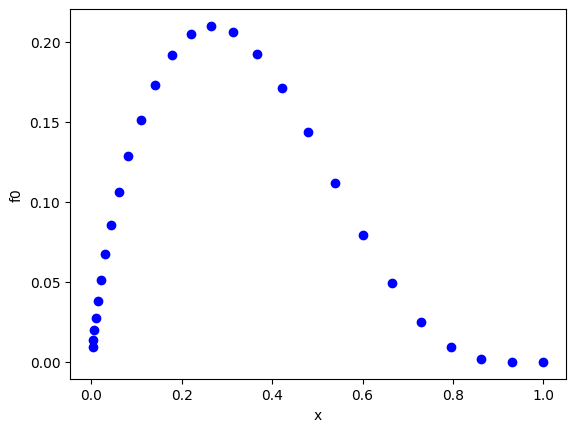

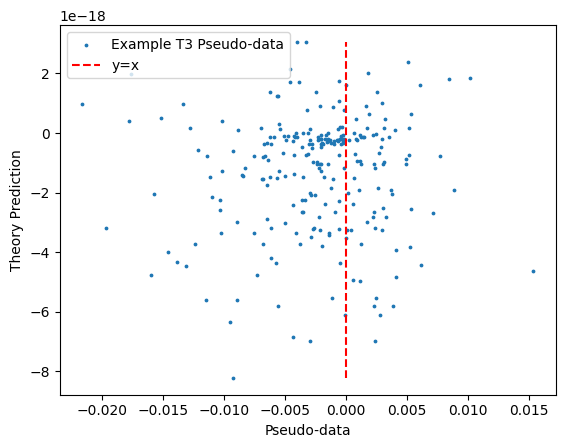

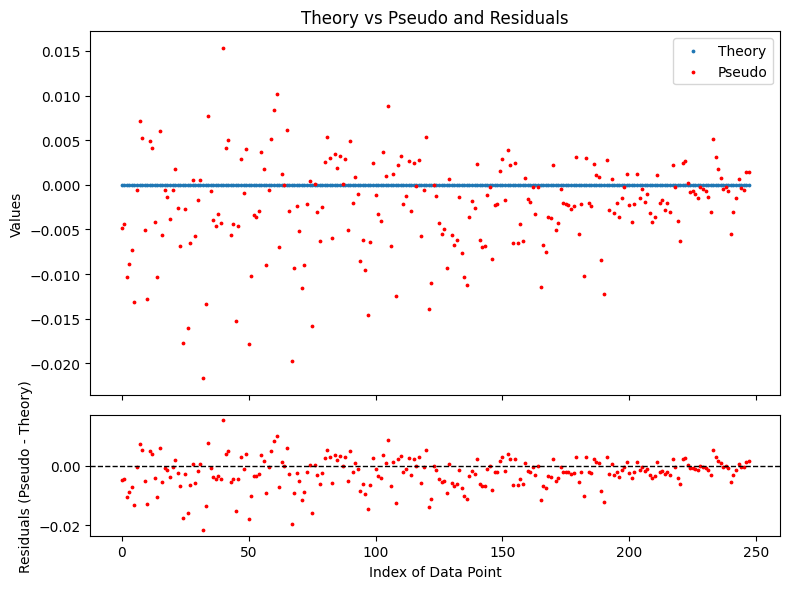

In [8]:
plt.scatter(xgrid2, xt3_true2, label="Example f0", color="blue")
plt.xlabel("x")
plt.ylabel("f0")
plt.show()
plt.close()

plt.scatter(y_pseudo2, y_theory2, label="Example T3 Pseudo-data",s=3)
plt.plot([min(y_theory2), max(y_theory2)],[min(y_theory2), max(y_theory2)], color="red", linestyle="--", label="y=x")

plt.legend()
plt.xlabel("Pseudo-data")
plt.ylabel("Theory Prediction")
plt.show()
plt.close()

residuals = y_pseudo2 - y_theory2

# Create two vertically stacked subplots (shared x-axis)
fig, (ax1, ax2) = plt.subplots(
    2, 1, 
    figsize=(8, 6), 
    gridspec_kw={'height_ratios': [3, 1]}, 
    sharex=True
)

# --- Top plot: theory vs pseudo
ax1.scatter(np.arange(len(y_theory2)), y_theory2, s=3, label='Theory')
ax1.scatter(np.arange(len(y_pseudo2)), y_pseudo2, s=3, label='Pseudo',color='r')
ax1.legend()
ax1.set_ylabel("Values")
ax1.set_title("Theory vs Pseudo and Residuals")

# --- Bottom plot: residuals
ax2.scatter(np.arange(len(residuals)), residuals, s=3, color='r')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_xlabel("Index of Data Point")
ax2.set_ylabel("Residuals (Pseudo - Theory)")

plt.tight_layout()
plt.show()
